In [301]:
###import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report
import numpy as np

In [303]:
###load data
df=pd.read_csv('health_activity_data.csv')

In [305]:
###preview data
df.head()

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Blood_Pressure,Exercise_Hours_per_Week,Smoker,Alcohol_Consumption_per_Week,Diabetic,Heart_Disease
0,1,56,Male,164,81,30.72,5134,1796,8.6,102,137/72,8.1,No,7,No,No
1,2,69,Male,156,82,20.86,12803,1650,4.5,103,129/65,3.7,No,7,No,No
2,3,46,Female,158,65,30.93,16408,1756,4.3,74,127/68,3.2,Yes,0,No,No
3,4,32,Male,197,87,31.19,18420,2359,4.1,116,125/86,8.5,No,5,No,No
4,5,60,Male,157,63,29.37,17351,2556,5.1,111,100/64,8.5,Yes,8,No,No


In [307]:
# check for any missing values
df.isnull().sum()

ID                              0
Age                             0
Gender                          0
Height_cm                       0
Weight_kg                       0
BMI                             0
Daily_Steps                     0
Calories_Intake                 0
Hours_of_Sleep                  0
Heart_Rate                      0
Blood_Pressure                  0
Exercise_Hours_per_Week         0
Smoker                          0
Alcohol_Consumption_per_Week    0
Diabetic                        0
Heart_Disease                   0
dtype: int64

In [309]:
#get first look at data with summary and data types
df.describe()

,ID,Age,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Exercise_Hours_per_Week,Alcohol_Consumption_per_Week
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,49.857000,174.74500,84.35200,26.729510,10717.034000,2327.117000,6.90990,84.710000,5.045500,4.573000
std,288.819436,18.114267,14.54192,20.06596,4.786341,5444.707891,657.847942,1.77964,20.130155,2.847801,2.852509
min,1.000000,18.000000,150.00000,50.00000,18.500000,1016.000000,1201.000000,4.00000,50.000000,0.000000,0.000000
25%,250.750000,35.000000,162.00000,68.00000,22.600000,6028.250000,1745.750000,5.30000,67.000000,2.675000,2.000000
50%,500.500000,50.000000,175.00000,84.00000,26.800000,10898.000000,2328.500000,6.90000,84.000000,5.100000,5.000000
75%,750.250000,66.000000,187.00000,101.00000,30.850000,15253.250000,2880.000000,8.40000,103.000000,7.600000,7.000000
max,1000.000000,79.000000,199.00000,119.00000,34.980000,19931.000000,3498.000000,10.00000,119.000000,10.000000,9.000000


In [310]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   object 
 3   Height_cm                     1000 non-null   int64  
 4   Weight_kg                     1000 non-null   int64  
 5   BMI                           1000 non-null   float64
 6   Daily_Steps                   1000 non-null   int64  
 7   Calories_Intake               1000 non-null   int64  
 8   Hours_of_Sleep                1000 non-null   float64
 9   Heart_Rate                    1000 non-null   int64  
 10  Blood_Pressure                1000 non-null   object 
 11  Exercise_Hours_per_Week       1000 non-null   float64
 12  Smoker                        1000 non-null   object 
 13  Alco

In [313]:
# check for any duplicated values
df.duplicated().sum()

0

### Visualizations

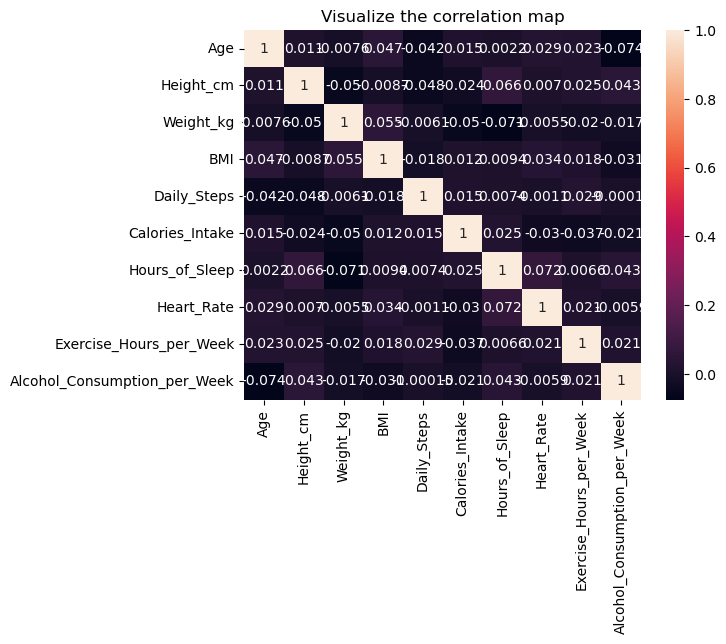

In [316]:
# Visualize the Correlation map
corr=df[['Age','Height_cm','Weight_kg','BMI','Daily_Steps','Calories_Intake','Hours_of_Sleep','Heart_Rate','Exercise_Hours_per_Week','Alcohol_Consumption_per_Week']].corr()
sns.heatmap(corr,annot=True)
plt.title("Visualize the correlation map")
plt.show()

Average age: 49.857


<Axes: xlabel='Age', ylabel='Count'>

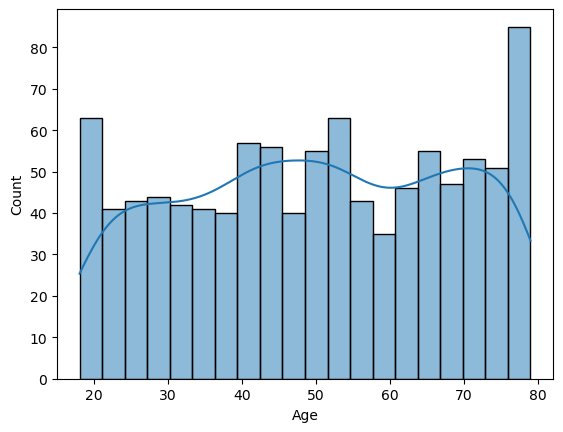

In [317]:
#distribution of age
avg_age=df['Age'].mean()
print('Average age:', avg_age)

sns.histplot(df['Age'], bins=20, kde=True)

Average height: 174.745


<Axes: xlabel='Height_cm', ylabel='Count'>

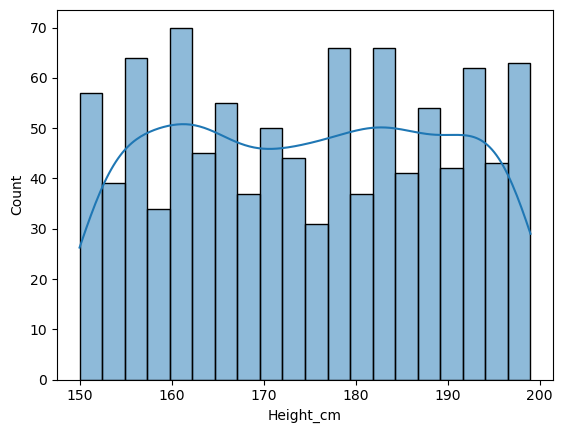

In [319]:
#distribution of height
avg_height=df['Height_cm'].mean()
print('Average height:', avg_height)

sns.histplot(df['Height_cm'], bins=20, kde=True)

Average weight: 49.857


<Axes: xlabel='Weight_kg', ylabel='Count'>

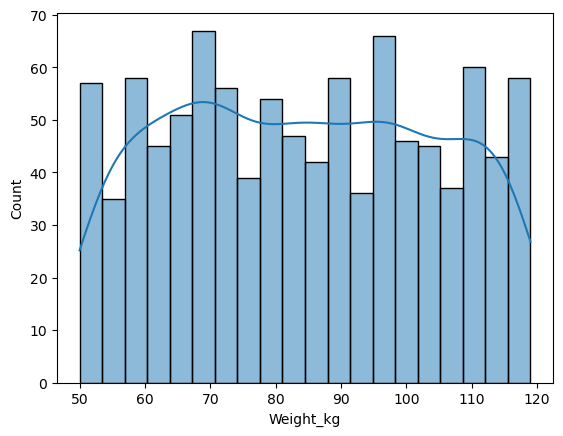

In [320]:
#distribution of weight
avg_weight=df['Weight_kg'].mean()
print('Average weight:', avg_age)

sns.histplot(df['Weight_kg'], bins=20, kde=True)

Heart Disease Distribution:
 Heart_Disease
No     907
Yes     93
Name: count, dtype: int64


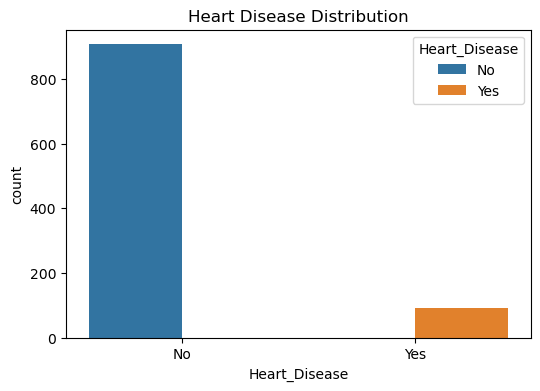

In [322]:
#distribution of heart disease
HD_ratio=df['Heart_Disease'].value_counts()
print('Heart Disease Distribution:\n', HD_ratio)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Heart_Disease', hue= 'Heart_Disease')
plt.title('Heart Disease Distribution')
plt.show()

Diabetic Distribution:
 Diabetic
No     845
Yes    155
Name: count, dtype: int64


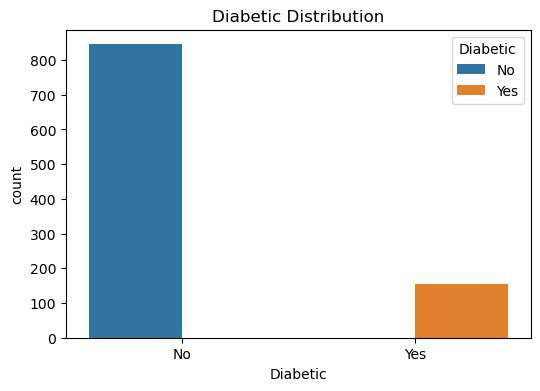

In [324]:
#distribution of diabetes
D_ratio=df['Diabetic'].value_counts()
print('Diabetic Distribution:\n', D_ratio)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Diabetic', hue= 'Diabetic')
plt.title('Diabetic Distribution')
plt.show()

# Prepare Data for Regression Models

In [327]:
#split data into X and y
df.columns
columns_to_drop = ['BMI', 'Blood_Pressure', 'ID']
X = df.drop(columns=columns_to_drop, axis=1)

y=df['BMI']
X.sample()

,Age,Gender,Height_cm,Weight_kg,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Exercise_Hours_per_Week,Smoker,Alcohol_Consumption_per_Week,Diabetic,Heart_Disease
675,62,Female,157,57,14158,2357,8.1,74,6.6,No,6,Yes,No


In [330]:
#encode the categorical data
X_encoded=pd.get_dummies(X, drop_first=True)
X_encoded.sample()

,Age,Height_cm,Weight_kg,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Exercise_Hours_per_Week,Alcohol_Consumption_per_Week,Gender_Male,Smoker_Yes,Diabetic_Yes,Heart_Disease_Yes
770,34,183,115,19028,2471,9.6,64,1.3,9,False,False,False,False


In [333]:
#split the data into training and tet sets
X_train, X_test, y_train, y_test=train_test_split(X_encoded,
                                                  y,
                                                  test_size=.20,
                                                  random_state=0)

# Linear Regression to predict BMI

In [336]:
#train the linear model
linear_model=LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [338]:
#validate the model
y_pred_linear=linear_model.predict(X_test)

In [340]:
# calculate and print performance metrics
mse=mean_squared_error(y_test, y_pred_linear)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred_linear)
#printing
print(f'Mean squared error:{mse:.2f}')
print(f'Root Mean squared error:{rmse:.2f}')
print(f'Mean squared error:{r2:.2f}')

Mean squared error:23.04
Root Mean squared error:4.80
Mean squared error:-0.01


In [342]:
#create an input to predict BMI
X_encoded.sample()
linear_model.predict([[21,187,118,9000,3300,8,60,4,10,1,0,0,0]])

/Users/williammuckler/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([26.8428603])

# Logistic Regression to Predict Heart Disease

In [345]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_class_train, y_class_train)

In [347]:
# Initialize and train the model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_class_train, y_class_train)

# Make predictions
y_class_pred = log_reg.predict(X_class_test)

NameError: name 'X_class_train' is not defined